In [4]:
import pandas as pd # manipuler les tableaux de données
import numpy as np # calculs mathématiques
import matplotlib.pyplot as plt # dessiner des graphiques
import seaborn as sns # graphiques plus beaux que matplotlib
%pip install statsmodels
from statsmodels.stats.outliers_influence import variance_inflation_factor
# afficher les graphiques dans le notebook
%matplotlib inline
print("Imports OK ✅") 

     ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
     ---------------------------------------- 0.0/9.6 MB 660.6 kB/s eta 0:00:15
     ---------------------------------------- 0.0/9.6 MB 660.6 kB/s eta 0:00:15
     ---------------------------------------- 0.1/9.6 MB 491.5 kB/s eta 0:00:20
     ---------------------------------------- 0.1/9.6 MB 585.1 kB/s eta 0:00:17
      --------------------------------------- 0.2/9.6 MB 845.5 kB/s eta 0:00:12
      --------------------------------------- 0.2/9.6 MB 850.1 kB/s eta 0:00:11
     - -------------------------------------- 0.3/9.6 MB 896.4 kB/s eta 0:00:11
     - -------------------------------------- 0.4/9.6 MB 1.1 MB/s eta 0:00:09
     -- ------------------------------------- 0.6/9.6 MB 1.3 MB/s eta 0:00:07
     -- ------------------------------------- 0.7/9.6 MB 1.5 MB/s eta 0:00:06
     --- ------------------------------------ 0.9/9.6 MB 1.7 MB/s eta 0:00:05
     --- ------------------------------------ 0.9/9.6 MB 


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Imports OK ✅


In [ ]:
df = pd.read_csv('../data/raw/retail_customers_COMPLETE_CATEGORICAL.csv') # on va lire le fichier csv et le transformer en Dataframe
print(f"Lignes : {df.shape[0]}")
print(f"Colonnes : {df.shape[1]}")
df.head()

Lignes : 4372
Colonnes : 52


In [5]:
print("=== TYPES DES COLONNES ===")
print(df.dtypes)

=== TYPES DES COLONNES ===
CustomerID                     int64
Recency                        int64
Frequency                      int64
MonetaryTotal                float64
MonetaryAvg                  float64
MonetaryStd                  float64
MonetaryMin                  float64
MonetaryMax                  float64
TotalQuantity                  int64
AvgQuantityPerTransaction    float64
MinQuantity                    int64
MaxQuantity                    int64
CustomerTenureDays             int64
FirstPurchaseDaysAgo           int64
PreferredDayOfWeek             int64
PreferredHour                  int64
PreferredMonth                 int64
WeekendPurchaseRatio         float64
AvgDaysBetweenPurchases      float64
UniqueProducts                 int64
UniqueDescriptions             int64
AvgProductsPerTransaction    float64
UniqueCountries                int64
NegativeQuantityCount          int64
ZeroPriceCount                 int64
CancelledTransactions          int64
ReturnRatio

In [ ]:
print("=== VALEURS MANQUANTES ===")
manquantes = df.isnull().sum() # creer un tableau de true/false 
manquantes_pct = (df.isnull().sum() / len(df) * 100).round(2) # donner le pourcentage des valeurs manquantes 

resultat = pd.DataFrame({
    'Manquantes': manquantes,
    'Pourcentage %': manquantes_pct
})

# Afficher seulement les colonnes qui ont des valeurs manquantes
print(resultat[resultat['Manquantes'] > 0])

# Vérification critère >50% manquantes
print("\n⚠️ Colonnes avec >50% manquantes (à supprimer) :")
cols_50 = resultat[resultat['Pourcentage %'] > 50]
if len(cols_50) == 0:
    print("   Aucune colonne avec >50% manquantes")
else:
    print(cols_50)

=== VALEURS MANQUANTES ===
                         Manquantes  Pourcentage %
AvgDaysBetweenPurchases          79           1.81
Age                            1311          29.99


=== DISTRIBUTION CHURN ===
Churn
0    2918
1    1454
Name: count, dtype: int64

Pourcentage churners : 33.3%


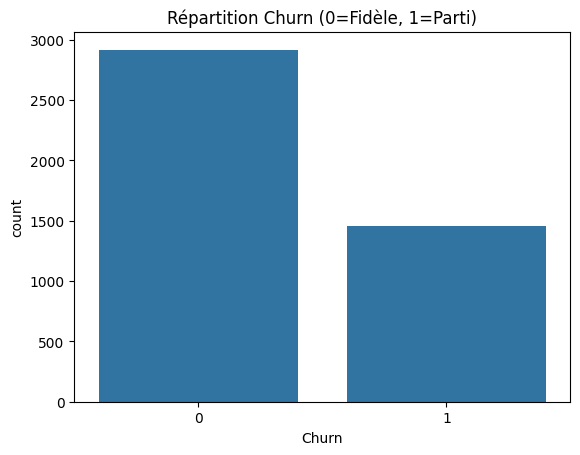

In [ ]:
print("=== DISTRIBUTION CHURN ===")
print(df['Churn'].value_counts())
print(f"\nPourcentage churners : {df['Churn'].mean()*100:.1f}%")

# Graphique
sns.countplot(x='Churn', data=df)
plt.title('Répartition Churn (0=Fidèle, 1=Parti)')
plt.xlabel('Churn')
plt.ylabel('Nombre de clients')
plt.show()

In [8]:
print("=== STATISTIQUES DE BASE ===")
df.describe().round(2) #calcule automatiquement pour chaque colonne numérique : count, mean, std, min, 25%, 50%, 75%, max. 

=== STATISTIQUES DE BASE ===


,CustomerID,Recency,Frequency,MonetaryTotal,MonetaryAvg,MonetaryStd,MonetaryMin,MonetaryMax,TotalQuantity,AvgQuantityPerTransaction,...,ZeroPriceCount,CancelledTransactions,ReturnRatio,TotalTransactions,UniqueInvoices,AvgLinesPerInvoice,Age,SupportTicketsCount,SatisfactionScore,Churn
count,4372.00,4372.00,4372.00,4372.00,4372.00,4372.00,4372.00,4372.00,4372.00,4372.00,...,4372.00,4372.00,4372.00,4372.00,4372.00,4372.00,3061.00,4372.00,4372.00,4372.00
mean,15299.68,92.05,5.08,1898.46,28.84,88.67,-86.43,185.18,1122.34,22.39,...,0.01,2.04,0.03,93.05,5.08,19.88,49.15,21.78,5.33,0.33
std,1722.39,100.77,9.34,8219.35,127.32,2689.00,2876.40,2881.28,4672.79,213.26,...,0.13,7.34,0.11,232.47,9.34,18.51,18.27,139.27,15.41,0.47
min,12346.00,1.00,1.00,-4287.63,-4287.63,0.00,-168469.60,-4287.63,-303.00,-144.00,...,0.00,0.00,0.00,1.00,1.00,1.00,18.00,-1.00,-1.00,0.00
25%,13812.75,17.00,1.00,293.36,10.99,6.23,-11.50,31.80,153.00,5.48,...,0.00,0.00,0.00,17.00,1.00,8.00,34.00,1.00,2.00,0.00
50%,15300.50,50.00,3.00,648.08,16.92,10.35,0.79,52.02,365.00,9.49,...,0.00,0.00,0.00,42.00,3.00,14.60,49.00,2.00,3.00,0.00
75%,16778.25,143.00,5.00,1611.72,23.54,20.63,6.96,102.00,962.25,14.01,...,0.00,1.00,0.02,102.00,5.00,25.21,65.00,3.00,4.00,1.00
max,18287.00,374.00,248.00,279489.02,3861.00,137554.85,3861.00,168469.60,196719.00,12540.00,...,4.00,226.00,1.00,7983.00,248.00,219.00,80.00,999.00,99.00,1.00


on a les colonnes  SupportTicketsCount et SatisfactionScore contiennent des valeurs aberrantes : 
on va faire des histogrammes pour montrer ca avec:
Axe X (horizontal) = la VALEUR de la feature (ex: 0, 1, 2 ... 999 tickets)
Axe Y (vertical) = le NOMBRE DE CLIENTS qui ont cette valeur

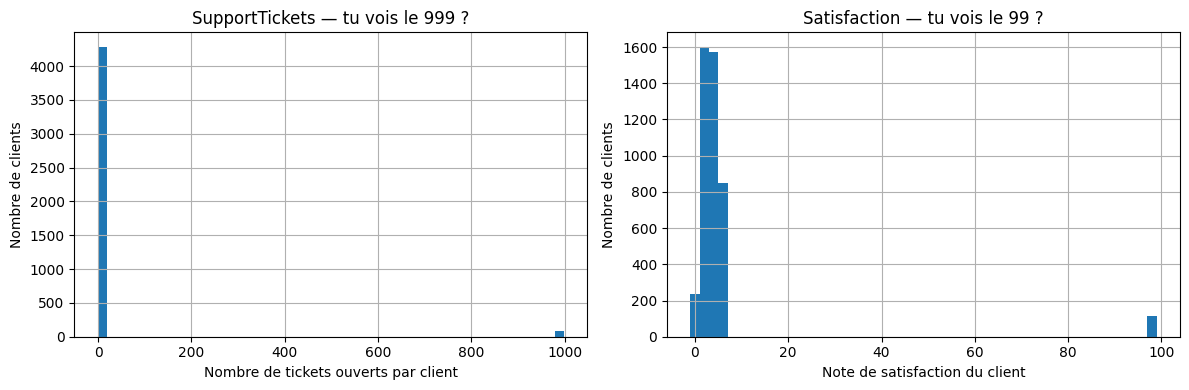

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Graphe 1 : SupportTicketsCount ---
df['SupportTicketsCount'].hist(bins=50, ax=axes[0])
axes[0].set_title('SupportTickets — tu vois le 999 ?')
axes[0].set_xlabel('Nombre de tickets ouverts par client')  # légende axe X
axes[0].set_ylabel('Nombre de clients')                     # légende axe Y

# --- Graphe 2 : SatisfactionScore ---
df['SatisfactionScore'].hist(bins=50, ax=axes[1])
axes[1].set_title('Satisfaction — tu vois le 99 ?')
axes[1].set_xlabel('Note de satisfaction du client')        # légende axe X
axes[1].set_ylabel('Nombre de clients')                     # légende axe Y

plt.tight_layout()
plt.show()

In [10]:
# Afficher toutes les colonnes du dataset
print(df.columns.tolist())

['CustomerID', 'Recency', 'Frequency', 'MonetaryTotal', 'MonetaryAvg', 'MonetaryStd', 'MonetaryMin', 'MonetaryMax', 'TotalQuantity', 'AvgQuantityPerTransaction', 'MinQuantity', 'MaxQuantity', 'CustomerTenureDays', 'FirstPurchaseDaysAgo', 'PreferredDayOfWeek', 'PreferredHour', 'PreferredMonth', 'WeekendPurchaseRatio', 'AvgDaysBetweenPurchases', 'UniqueProducts', 'UniqueDescriptions', 'AvgProductsPerTransaction', 'UniqueCountries', 'NegativeQuantityCount', 'ZeroPriceCount', 'CancelledTransactions', 'ReturnRatio', 'TotalTransactions', 'UniqueInvoices', 'AvgLinesPerInvoice', 'Age', 'RegistrationDate', 'NewsletterSubscribed', 'LastLoginIP', 'SupportTicketsCount', 'SatisfactionScore', 'RFMSegment', 'AgeCategory', 'SpendingCategory', 'CustomerType', 'FavoriteSeason', 'PreferredTimeOfDay', 'Region', 'LoyaltyLevel', 'ChurnRiskCategory', 'WeekendPreference', 'BasketSizeCategory', 'ProductDiversity', 'Gender', 'AccountStatus', 'Country', 'Churn']


=== MATRICE DE CORRÉLATION ===
⚠️ CORRÉLATIONS FORTES DÉTECTÉES (à surveiller pour multicolinéarité) :
  MonetaryMin ↔ MonetaryStd : -0.97
  MonetaryMax ↔ MonetaryStd : 0.97
  MonetaryMax ↔ MonetaryMin : -0.99
  TotalQuantity ↔ MonetaryTotal : 0.92
  MinQuantity ↔ MonetaryStd : -0.97
  MinQuantity ↔ MonetaryMin : 0.92
  MinQuantity ↔ MonetaryMax : -0.92
  MaxQuantity ↔ MonetaryStd : 0.97
  MaxQuantity ↔ MonetaryMin : -0.92
  MaxQuantity ↔ MonetaryMax : 0.92


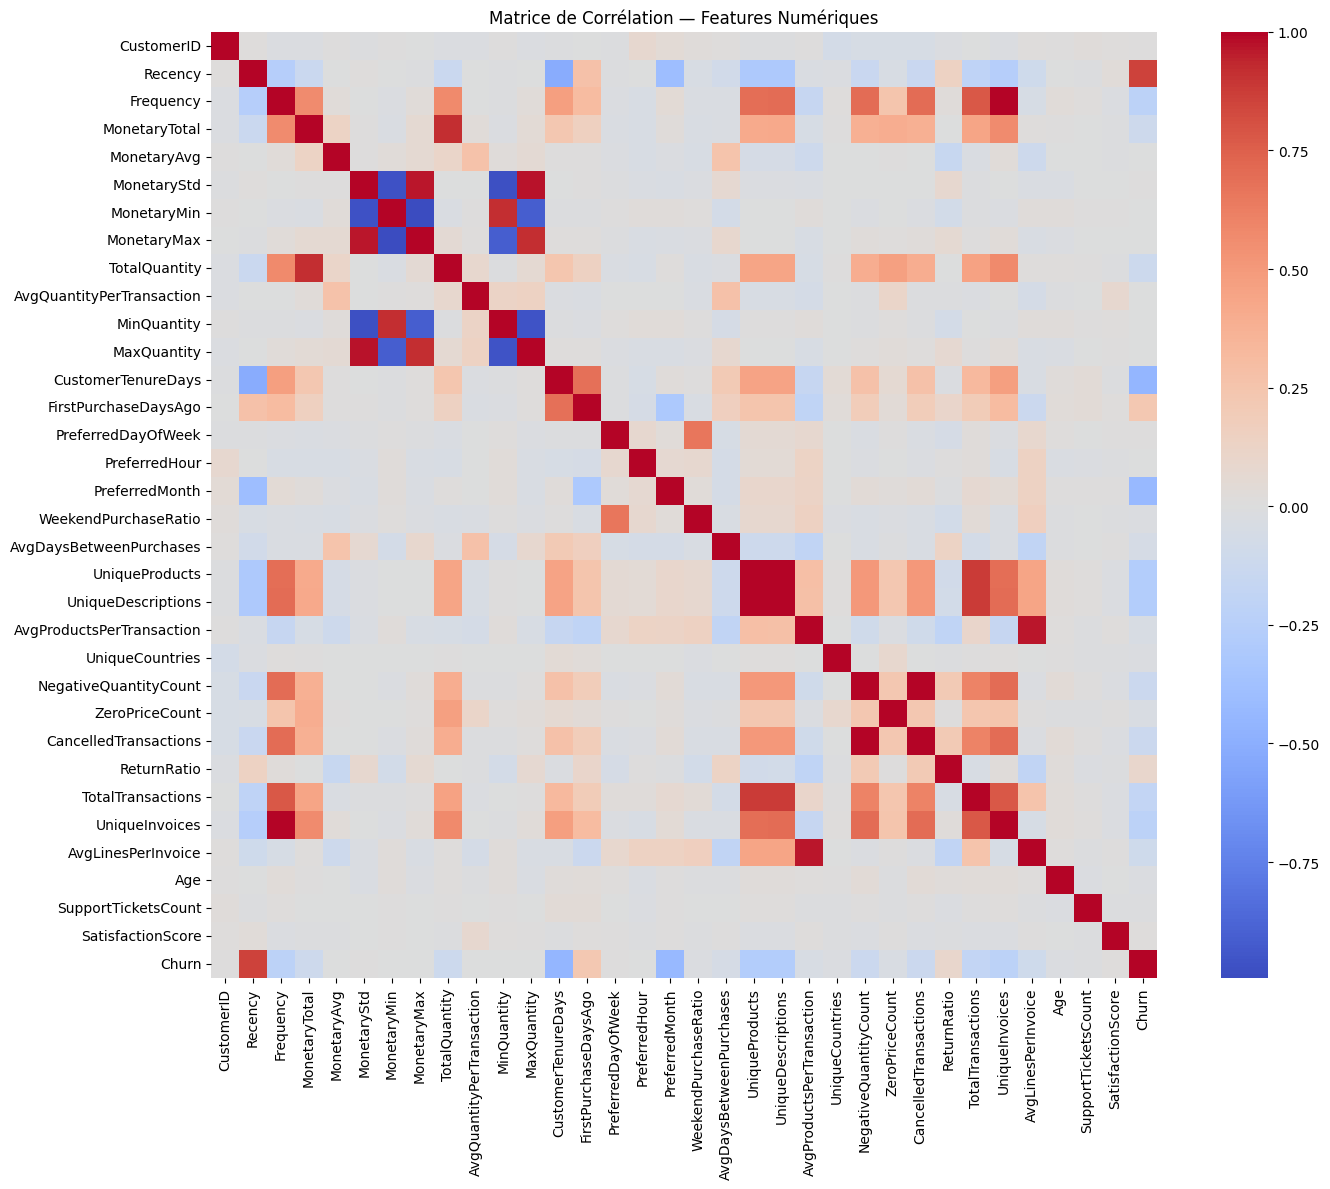

In [ ]:
# Matrice de corrélation — Section 6.2 du cahier des charges
print("=== MATRICE DE CORRÉLATION ===")

# Sélectionner seulement les colonnes numériques
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()# garde seulement les colonnes numeriques

# Calculer la corrélation
corr_matrix = df[num_cols].corr() # calculer le coeff de correlation de Pearson entre toutes les paires de colonnes :Résultat : un tableau carré N×N avec des valeurs entre -1 et +1. 
#+1 = corrélation parfaite positive, -1 = parfaite négative, 0 = aucune relation.

# Afficher les corrélations fortes (> 0.8 ou < -0.8)
strong_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):# j < i évite de compter deux fois la même paire (A↔B = B↔A) et d'inclure la diagonale (A↔A = toujours 1.0).
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            strong_corr.append({
                'Feature1': corr_matrix.columns[i],
                'Feature2': corr_matrix.columns[j],
                'Corrélation': round(corr_matrix.iloc[i, j], 2)
            })

if strong_corr:
    print("⚠️ CORRÉLATIONS FORTES DÉTECTÉES (à surveiller pour multicolinéarité) :")
    for item in strong_corr[:10]:  # Afficher les 10 premières
        print(f"  {item['Feature1']} ↔ {item['Feature2']} : {item['Corrélation']}")
else:
    print("✅ Aucune corrélation forte détectée")

# Visualisation heatmap
plt.figure(figsize=(15, 12))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, square=True) #transforme le tableau de corrélation en image colorée
plt.title('Matrice de Corrélation — Features Numériques')
plt.tight_layout()
plt.show()

In [ ]:
print("=== VIF — VARIANCE INFLATION FACTOR ===")
from statsmodels.stats.outliers_influence import variance_inflation_factor

num_df = df[num_cols].dropna()
vif_data = pd.DataFrame()
vif_data['Feature'] = num_df.columns
vif_data['VIF'] = [variance_inflation_factor(num_df.values, i)
                   for i in range(num_df.shape[1])]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("⚠️ Features avec VIF > 10 (multicolinéarité sévère) :")
print(vif_data[vif_data['VIF'] > 10].to_string(index=False))
print("\nTop 10 VIF :")
print(vif_data.head(10).to_string(index=False))

In [ ]:
# === ANALYSE DES FEATURES CATÉGORIELLES ===
print("=== FEATURES CATÉGORIELLES ===\n")

cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Nombre de features catégorielles : {len(cat_cols)}")
print(f"Liste : {cat_cols}\n")

#Pour chaque colonne catégorielle, on affiche toutes ses valeurs et leur fréquence.
for col in cat_cols:
    print(f"--- {col} ---")
    print(df[col].value_counts(dropna=False))#inclure aussi les NaN dans le comptage pour ne pas les cacher.
    print()

=== FEATURES CATÉGORIELLES ===

Nombre de features catégorielles : 18
Liste : ['RegistrationDate', 'NewsletterSubscribed', 'LastLoginIP', 'RFMSegment', 'AgeCategory', 'SpendingCategory', 'CustomerType', 'FavoriteSeason', 'PreferredTimeOfDay', 'Region', 'LoyaltyLevel', 'ChurnRiskCategory', 'WeekendPreference', 'BasketSizeCategory', 'ProductDiversity', 'Gender', 'AccountStatus', 'Country']

--- RegistrationDate ---
RegistrationDate
12/10/2010    11
2010-12-21    11
01/01/2011    10
10/01/11      10
2010-12-22    10
              ..
2011-12-05     1
24/10/11       1
2011-12-13     1
10/01/2011     1
07/12/11       1
Name: count, Length: 1700, dtype: int64

--- NewsletterSubscribed ---
NewsletterSubscribed
Yes    4372
Name: count, dtype: int64

--- LastLoginIP ---
LastLoginIP
154.168.54.141     1
59.252.219.201     1
77.255.247.14      1
51.139.78.80       1
219.176.193.197    1
                  ..
199.225.35.180     1
98.239.241.45      1
154.102.135.173    1
206.53.156.18      1
186.34.

In [13]:
# === VÉRIFICATION FORMATS REGISTRATIONDATE ===
print("=== FORMATS INCONSISTANTS — RegistrationDate ===\n")

print("Exemples de valeurs brutes :")
print(df['RegistrationDate'].dropna().head(20).tolist())

print(f"\nNombre de valeurs uniques : {df['RegistrationDate'].nunique()}")
print(f"Valeurs manquantes : {df['RegistrationDate'].isnull().sum()}")

# Détecter les différents formats
import re

def detecter_format(date_str):
    if pd.isna(date_str):
        return 'NaN'
    elif re.match(r'^\d{4}-\d{2}-\d{2}$', str(date_str)):
        return 'ISO (2010-12-21)'
    elif re.match(r'^\d{2}/\d{2}/\d{4}$', str(date_str)):
        return 'UK long (21/12/2010)'
    elif re.match(r'^\d{2}/\d{2}/\d{2}$', str(date_str)):
        return 'UK court (21/12/10)'
    else:
        return 'Autre'

df['format_detecte'] = df['RegistrationDate'].apply(detecter_format)
print("\nDistribution des formats :")
print(df['format_detecte'].value_counts())
df.drop(columns=['format_detecte'], inplace=True)

=== FORMATS INCONSISTANTS — RegistrationDate ===

Exemples de valeurs brutes :
['17/07/10', '2010-10-04', '12/09/2009', '28/01/10', '2009-12-10', '10/18/2010', '02/11/10', '2010-12-17', '09/23/2010', '04/09/10', '2010-12-27', '10/02/2010', '17/09/10', '2010-09-28', '11/25/2010', '12/09/10', '2010-09-19', '07/28/2010', '24/10/10', '2010-06-12']

Nombre de valeurs uniques : 1700
Valeurs manquantes : 0

Distribution des formats :
format_detecte
UK court (21/12/10)     1458
ISO (2010-12-21)        1457
UK long (21/12/2010)    1457
Name: count, dtype: int64


In [ ]:
# === FEATURES SPÉCIALES ===

# NewsletterSubscribed — valeur constante ?
print("=== NewsletterSubscribed ===")
print(df['NewsletterSubscribed'].value_counts(dropna=False))
print(f"→ Valeurs uniques : {df['NewsletterSubscribed'].nunique()}") # compter les valeurs uniques de cette colonnes 
print("→ Conclusion : feature à SUPPRIMER (variance nulle)\n")

# LastLoginIP — données brutes
print("=== LastLoginIP ===")
print(df['LastLoginIP'].head(10))
print(f"\nNombre de valeurs uniques : {df['LastLoginIP'].nunique()}")# pour confirmer que se sont des donnees brutes 
print("→ Conclusion : à transformer (détecter IP privée/publique)")

=== NewsletterSubscribed ===
NewsletterSubscribed
Yes    4372
Name: count, dtype: int64
→ Valeurs uniques : 1
→ Conclusion : feature à SUPPRIMER (variance nulle)

=== LastLoginIP ===
0     59.252.219.201
1      77.255.247.14
2       51.139.78.80
3      10.212.80.124
4      186.34.121.80
5      206.53.156.18
6    154.102.135.173
7      98.239.241.45
8     199.225.35.180
9     114.231.21.241
Name: LastLoginIP, dtype: object

Nombre de valeurs uniques : 4372
→ Conclusion : à transformer (détecter IP privée/publique)


In [15]:
# === RÉCAPITULATIF PROBLÈMES DE QUALITÉ ===
print("=" * 55)
print("   RAPPORT D'EXPLORATION — PROBLÈMES DÉTECTÉS")
print("=" * 55)

print("\n1. VALEURS MANQUANTES")
manquantes = df.isnull().sum()
for col in manquantes[manquantes > 0].index:
    pct = manquantes[col] / len(df) * 100
    print(f"   - {col} : {manquantes[col]} valeurs ({pct:.1f}%)")

print("\n2. VALEURS ABERRANTES")
print(f"   - SupportTicketsCount : {(df['SupportTicketsCount'] == 999).sum()} lignes avec 999")
print(f"   - SupportTicketsCount : {(df['SupportTicketsCount'] == -1).sum()} lignes avec -1")
print(f"   - SatisfactionScore   : {(df['SatisfactionScore'] == 99).sum()} lignes avec 99")
print(f"   - SatisfactionScore   : {(df['SatisfactionScore'] == -1).sum()} lignes avec -1")

print("\n3. FORMATS INCONSISTANTS")
print(f"   - RegistrationDate : 3 formats mélangés (ISO / UK long / UK court)")

print("\n4. FEATURE INUTILE (variance nulle)")
print(f"   - NewsletterSubscribed : valeur unique = '{df['NewsletterSubscribed'].iloc[0]}'")

print("\n5. DÉSÉQUILIBRE DES CLASSES")
churn_pct = df['Churn'].mean() * 100
print(f"   - Churn : {churn_pct:.1f}% churners vs {100-churn_pct:.1f}% fidèles")

print("\n6. FEATURES À TRANSFORMER")
print(f"   - LastLoginIP      : extraire si IP privée/publique")
print(f"   - RegistrationDate : parser en datetime → extraire année/mois/jour")

print("\n7. CORRÉLATIONS FORTES DÉTECTÉES (multicolinéarité)")
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
corr_matrix = df[num_cols].corr()
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            print(f"   - {corr_matrix.columns[i]} ↔ {corr_matrix.columns[j]} : {corr_matrix.iloc[i,j]:.2f}")

print("\n" + "=" * 55)
print("→ PROCHAINE ÉTAPE : src/preprocessing.py")
print("=" * 55)

   RAPPORT D'EXPLORATION — PROBLÈMES DÉTECTÉS

1. VALEURS MANQUANTES
   - AvgDaysBetweenPurchases : 79 valeurs (1.8%)
   - Age : 1311 valeurs (30.0%)

2. VALEURS ABERRANTES
   - SupportTicketsCount : 87 lignes avec 999
   - SupportTicketsCount : 43 lignes avec -1
   - SatisfactionScore   : 114 lignes avec 99
   - SatisfactionScore   : 115 lignes avec -1

3. FORMATS INCONSISTANTS
   - RegistrationDate : 3 formats mélangés (ISO / UK long / UK court)

4. FEATURE INUTILE (variance nulle)
   - NewsletterSubscribed : valeur unique = 'Yes'

5. DÉSÉQUILIBRE DES CLASSES
   - Churn : 33.3% churners vs 66.7% fidèles

6. FEATURES À TRANSFORMER
   - LastLoginIP      : extraire si IP privée/publique
   - RegistrationDate : parser en datetime → extraire année/mois/jour

7. CORRÉLATIONS FORTES DÉTECTÉES (multicolinéarité)
   - MonetaryMin ↔ MonetaryStd : -0.97
   - MonetaryMax ↔ MonetaryStd : 0.97
   - MonetaryMax ↔ MonetaryMin : -0.99
   - TotalQuantity ↔ MonetaryTotal : 0.92
   - MinQuantity ↔ Monet